# Mini-Project 1 — Mandelbrot Set
**Course:** Numerical Scientific Computing  
**Program:** M.Sc. Computer Engineering  
**University:** Aalborg University  

## Objective
The goal of this mini-project is to implement and compare three versions of the Mandelbrot set computation:

1. A naïve pure Python implementation using nested loops  
2. A NumPy-based vectorized implementation  
3. A Numba-optimized implementation  

In this notebook I am to implement the Mandelbrot set in three different ways, and then, I am going to do the benchmarks to see the differences between each other.

## Problem description
This project is going to have 3 different checkpoints, in the first one we are going to develop a naive implementation using nested loops with python, in the second one we are going to develope a numpy vectorized grid, and last but not least a numba opmitized version.

With all three different implementations we are going to mesure the performance and the scaling analisys.



For this first implementation, lets establish the necessary milestones to successfylly develop the code.
 

Import the libraries

In [19]:
import os
import csv
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numba import njit

Define the region (x_min,x_max,y_min,y_max, width, height, max_iterations and escape_radius)

In [20]:
# Region in the complex plane
X_MIN, X_MAX = -2.0, 1.0
Y_MIN, Y_MAX = -1.5, 1.5

# Default parameters
DEFAULT_WIDTH = 400
DEFAULT_HEIGHT = 400
DEFAULT_MAX_ITER = 100
ESCAPE_RADIUS = 2.0

Define a general function to plot the results of the mandelbrot set

In [21]:
def plot_mandelbrot(data, title="Mandelbrot Set"):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        data,
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        origin="lower",
        cmap="hot"
    )
    plt.colorbar(label="Normalized escape value")
    plt.xlabel("Real part")
    plt.ylabel("Imaginary part")
    plt.title(title)
    plt.show()



Develop the different Mandelbrot implementations



## 1. Naïve implementation

This implementation uses pure Python and nested loops.
For each pixel in the image, a complex number \( c \) is created, and the Mandelbrot iteration is computed step by step until escape or until the maximum number of iterations is reached.

In [4]:
def mandelbrot_naive(width, height, max_iter):
    result = np.zeros((height, width), dtype=np.float64) #Create a 2D array to hold the escape values

    for row in range(height):
        for col in range(width):
            # Map pixel -> complex plane
            x = X_MIN + (col / (width - 1)) * (X_MAX - X_MIN) #Map pixel column to real part
            y = Y_MIN + (row / (height - 1)) * (Y_MAX - Y_MIN) #Map pixel row to imaginary part

            c = complex(x, y)  #Create complex number for the current pixel
            z = 0j

            escape_iter = max_iter #Initialize escape iteration count to max_iter (assume it does not escape)

            for n in range(max_iter):
                z = z * z + c #Iterate the Mandelbrot function
                if abs(z) > ESCAPE_RADIUS:#Check if the magnitude of z exceeds the escape radius
                    escape_iter = n + 1
                    break

            result[row, col] = escape_iter / max_iter #Normalize escape iteration count to [0, 1]

    return result

## 2. Numpy implementation



This implementation uses NyumPy arrays to represent the grid and applies vectorized operations to compute Mandelbrot iterations.

In [ ]:
def mandelbrot_numpy(width, height, max_iter):
    x = np.linspace(X_MIN, X_MAX, width)  # Create evenly spaced real-axis values
    y = np.linspace(Y_MIN, Y_MAX, height)  # Create evenly spaced imaginary-axis values
    X, Y = np.meshgrid(x, y)  # Build the full 2D grid of coordinates
    C = X + 1j * Y  # Create the complex grid C = x + iy for all pixels at once

    Z = np.zeros_like(C, dtype=np.complex128)  # Initialize Z to 0 for all points
    result = np.ones(C.shape, dtype=np.float64)  # Initialize result array; default 1.0 means "did not escape"
    active = np.ones(C.shape, dtype=bool)  # Boolean mask to track points that are still active

    for n in range(max_iter):
        Z[active] = Z[active] * Z[active] + C[active]  # Update only points that have not escaped yet

        escaped_now = np.abs(Z) > ESCAPE_RADIUS  # Check which points have exceeded the escape radius
        newly_escaped = escaped_now & active  # Keep only the points that escaped in this iteration

        result[newly_escaped] = (n + 1) / max_iter  # Store normalized escape iteration for newly escaped points
        active[newly_escaped] = False  # Mark newly escaped points as inactive

        if not np.any(active):
            break  # Stop early if all points have already escaped

    result[active] = 1.0  # Points still active after max_iter are considered inside the Mandelbrot set
    return result

## 3. Numba implementation

This implementation annotates iteration loops with njit so they compile fast, accelerating the Mandelbrot calculations

In [ ]:
@njit
def mandelbrot_numba(width, height, max_iter, x_min, x_max, y_min, y_max, escape_radius):
    result = np.zeros((height, width), dtype=np.float64)  # Create a 2D array to hold the escape values

    for row in range(height):
        for col in range(width):
            x = x_min + (col / (width - 1)) * (x_max - x_min)  # Map pixel column to real part
            y = y_min + (row / (height - 1)) * (y_max - y_min)  # Map pixel row to imaginary part

            cr = x  # Real part of the complex number c
            ci = y  # Imaginary part of the complex number c
            zr = 0.0  # Real part of z, initialized to 0
            zi = 0.0  # Imaginary part of z, initialized to 0

            escape_iter = max_iter  # Initialize escape iteration count to max_iter (assume it does not escape)

            for n in range(max_iter):
                zr_new = zr * zr - zi * zi + cr  # Compute new real part of z^2 + c
                zi_new = 2.0 * zr * zi + ci  # Compute new imaginary part of z^2 + c
                zr = zr_new  # Update real part of z
                zi = zi_new  # Update imaginary part of z

                if zr * zr + zi * zi > escape_radius * escape_radius:  # Check escape condition without square root
                    escape_iter = n + 1
                    break

            result[row, col] = escape_iter / max_iter  # Normalize escape iteration count to [0, 1]

    return result

After running the different functions, plot the Mandelbrot variations.

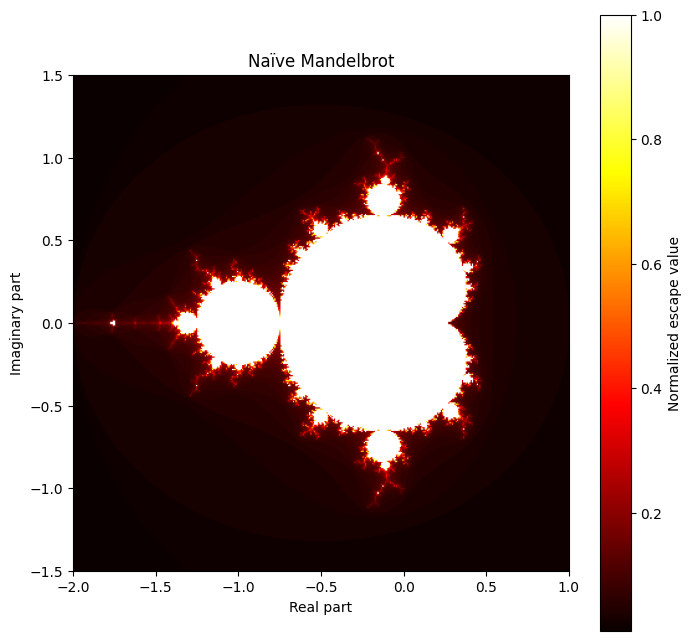

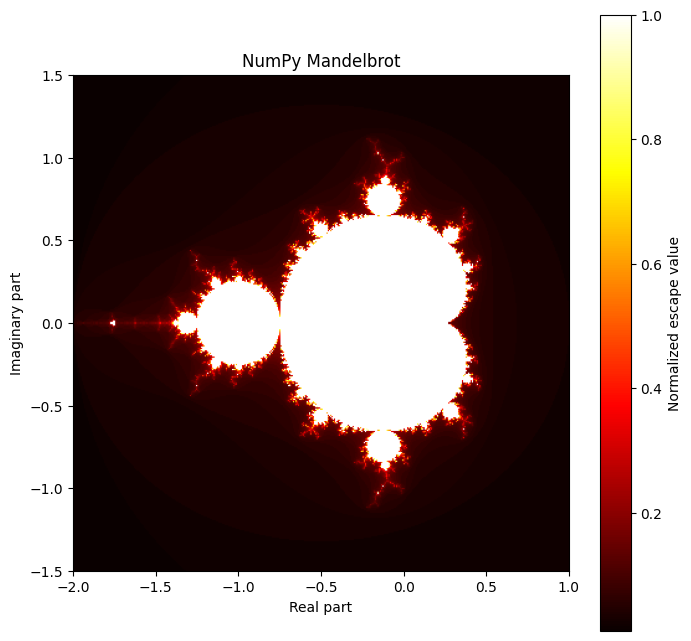

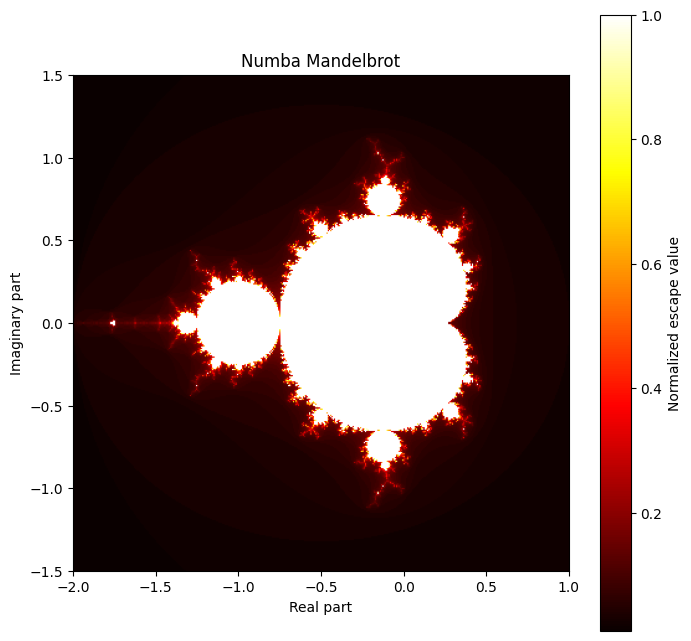

In [7]:
mandelbrot_naive_img = mandelbrot_naive(DEFAULT_WIDTH, DEFAULT_HEIGHT, DEFAULT_MAX_ITER)
mandelbrot_numpy_img = mandelbrot_numpy(DEFAULT_WIDTH, DEFAULT_HEIGHT, DEFAULT_MAX_ITER)
mandelbrot_numba_img = mandelbrot_numba(
    DEFAULT_WIDTH, DEFAULT_HEIGHT, DEFAULT_MAX_ITER,
    X_MIN, X_MAX, Y_MIN, Y_MAX, ESCAPE_RADIUS
)

plot_mandelbrot(mandelbrot_naive_img, "Naïve Mandelbrot")
plot_mandelbrot(mandelbrot_numpy_img, "NumPy Mandelbrot")
plot_mandelbrot(mandelbrot_numba_img, "Numba Mandelbrot")

After running the different Mandelbrot functions, we check if there are any differences between each other (close to 0 better).

In [8]:
print("Naive vs NumPy -> max abs diff:", np.max(np.abs(mandelbrot_naive_img - mandelbrot_numpy_img)))
print("Naive vs Numba -> max abs diff:", np.max(np.abs(mandelbrot_naive_img - mandelbrot_numba_img)))
print("NumPy vs Numba -> max abs diff:", np.max(np.abs(mandelbrot_numpy_img - mandelbrot_numba_img)))

Naive vs NumPy -> max abs diff: 0.0
Naive vs Numba -> max abs diff: 0.0
NumPy vs Numba -> max abs diff: 0.0


## 4. Benchmarks
 1. We define the different functions needed to calculate the runtime of each Mandelbrot set

In [9]:
def time_function(func, *args, repeats=3, **kwargs):
    times = []

    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    times = np.array(times, dtype=np.float64)
    return times.mean(), times.std(), times

In [10]:
def run_naive(size, max_iter):
    return mandelbrot_naive(size, size, max_iter)

def run_numpy(size, max_iter):
    return mandelbrot_numpy(size, size, max_iter)

def run_numba(size, max_iter):
    return mandelbrot_numba(
        size, size, max_iter,
        X_MIN, X_MAX, Y_MIN, Y_MAX, ESCAPE_RADIUS
    )

Numba warm-up (exclude JIT compilation time from benchmarking)


In [ ]:
_ = mandelbrot_numba(
    10, 10, 10,
    X_MIN, X_MAX, Y_MIN, Y_MAX, ESCAPE_RADIUS
)

In [ ]:
sizes = [100, 200, 400, 800, 1200]
max_iter_bench = 100
repeats = 3

results = []

implementations = {
    "naive": run_naive,
    "numpy": run_numpy,
    "numba": run_numba,
}

for size in sizes:
    print(f"\n=== Size: {size} x {size} ===")

    for name, func in implementations.items():
        if name == "naive" and size > 800:
            print(f"Skipping {name} for size {size} (too slow)")
            continue

        mean_t, std_t, raw_times = time_function(func, size, max_iter_bench, repeats=repeats)

        print(f"{name:>6} -> mean: {mean_t:.6f} s | std: {std_t:.6f} s | runs: {raw_times}")

        results.append({
            "implementation": name,
            "width": size,
            "height": size,
            "max_iter": max_iter_bench,
            "repeats": repeats,
            "mean_time_s": mean_t,
            "std_time_s": std_t
        })


=== Size: 100 x 100 ===
 naive -> mean: 0.054646 s | std: 0.001301 s | runs: [0.05343922 0.05645331 0.05404692]
 numpy -> mean: 0.010810 s | std: 0.000054 s | runs: [0.010885   0.01075854 0.01078614]
 numba -> mean: 0.000990 s | std: 0.000015 s | runs: [0.00101047 0.00097572 0.00098483]

=== Size: 200 x 200 ===


 naive -> mean: 0.227183 s | std: 0.027943 s | runs: [0.26669146 0.20813381 0.20672331]
 numpy -> mean: 0.034822 s | std: 0.000645 s | runs: [0.03568844 0.03463659 0.03414048]
 numba -> mean: 0.003901 s | std: 0.000023 s | runs: [0.00389524 0.0039324  0.00387598]

=== Size: 400 x 400 ===
 naive -> mean: 0.865152 s | std: 0.029864 s | runs: [0.84850915 0.90708896 0.8398575 ]
 numpy -> mean: 0.136237 s | std: 0.003013 s | runs: [0.13235095 0.13969369 0.13666565]
 numba -> mean: 0.015524 s | std: 0.000043 s | runs: [0.01552588 0.01547075 0.01557597]

=== Size: 800 x 800 ===
 naive -> mean: 3.379378 s | std: 0.004263 s | runs: [3.37423009 3.37923723 3.38466818]
 numpy -> mean: 0.649186 s | std: 0.055682 s | runs: [0.72793094 0.61009763 0.60952942]
 numba -> mean: 0.062618 s | std: 0.000613 s | runs: [0.06328828 0.06276049 0.06180635]

=== Size: 1200 x 1200 ===
Skipping naive for size 1200 (too slow)
 numpy -> mean: 1.592706 s | std: 0.107662 s | runs: [1.7443043  1.50466148 1.52915119]
 nu

In [13]:
df_results = pd.DataFrame(results)
df_results 

,implementation,width,height,max_iter,repeats,mean_time_s,std_time_s
0,naive,100,100,100,3,0.054646,0.001301
1,numpy,100,100,100,3,0.010810,0.000054
2,numba,100,100,100,3,0.000990,0.000015
3,naive,200,200,100,3,0.227183,0.027943
4,numpy,200,200,100,3,0.034822,0.000645
5,numba,200,200,100,3,0.003901,0.000023
6,naive,400,400,100,3,0.865152,0.029864
7,numpy,400,400,100,3,0.136237,0.003013
8,numba,400,400,100,3,0.015524,0.000043
9,naive,800,800,100,3,3.379378,0.004263


And then pour those results into a .csv

In [14]:
os.makedirs("results", exist_ok=True)

csv_path = "results/timings.csv"
df_results.to_csv(csv_path, index=False)

print(f"Saved timing results to: {csv_path}")

Saved timing results to: results/timings.csv


2. We calculate the speedup of each implementation with respect to the naive.

In [15]:
naive_df = df_results[df_results["implementation"] == "naive"][["width", "mean_time_s"]].copy()
naive_df = naive_df.rename(columns={"mean_time_s": "naive_time_s"})

speedup_df = df_results.merge(naive_df, on="width", how="inner")
speedup_df["speedup_vs_naive"] = speedup_df["naive_time_s"] / speedup_df["mean_time_s"]

speedup_df

,implementation,width,height,max_iter,repeats,mean_time_s,std_time_s,naive_time_s,speedup_vs_naive
0,naive,100,100,100,3,0.054646,0.001301,0.054646,1.000000
1,numpy,100,100,100,3,0.010810,0.000054,0.054646,5.055229
2,numba,100,100,100,3,0.000990,0.000015,0.054646,55.179531
3,naive,200,200,100,3,0.227183,0.027943,0.227183,1.000000
4,numpy,200,200,100,3,0.034822,0.000645,0.227183,6.524149
5,numba,200,200,100,3,0.003901,0.000023,0.227183,58.234038
6,naive,400,400,100,3,0.865152,0.029864,0.865152,1.000000
7,numpy,400,400,100,3,0.136237,0.003013,0.865152,6.350355
8,numba,400,400,100,3,0.015524,0.000043,0.865152,55.729250
9,naive,800,800,100,3,3.379378,0.004263,3.379378,1.000000


In this graph we compare how much the execution time increases of each implementation when the problem size increases.

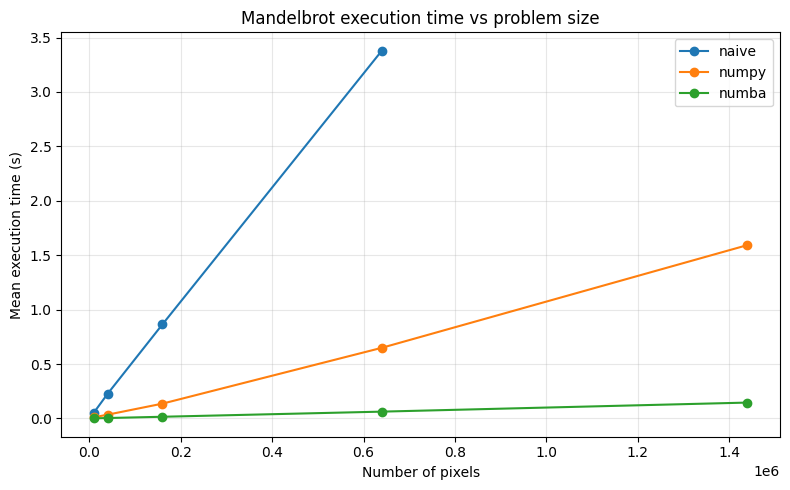

In [17]:
plt.figure(figsize=(8, 5))

for impl in df_results["implementation"].unique():
    sub = df_results[df_results["implementation"] == impl].sort_values("width")
    pixels = sub["width"] * sub["height"]
    plt.plot(pixels, sub["mean_time_s"], marker="o", label=impl)

plt.xlabel("Number of pixels")
plt.ylabel("Mean execution time (s)")
plt.title("Mandelbrot execution time vs problem size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After calculating all the things, we create a summary of the benchmarks.

In [18]:
print("Benchmark summary:")
display(df_results.sort_values(["implementation", "width"]))

Benchmark summary:


,implementation,width,height,max_iter,repeats,mean_time_s,std_time_s
0,naive,100,100,100,3,0.054646,0.001301
3,naive,200,200,100,3,0.227183,0.027943
6,naive,400,400,100,3,0.865152,0.029864
9,naive,800,800,100,3,3.379378,0.004263
2,numba,100,100,100,3,0.000990,0.000015
5,numba,200,200,100,3,0.003901,0.000023
8,numba,400,400,100,3,0.015524,0.000043
11,numba,800,800,100,3,0.062618,0.000613
13,numba,1200,1200,100,3,0.145810,0.003634
1,numpy,100,100,100,3,0.010810,0.000054
